In [1]:
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd
from collections import Counter
!pip install wordcloud
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from scipy.stats import mode
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.sparse import csr_matrix, csc_matrix
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ramma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ramma\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
#load the data
generic = pd.read_csv('GenericTweets.csv',low_memory=False)

In [3]:
generic.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
generic.shape

(27481, 4)

In [5]:
set(generic['sentiment'])

{'negative', 'neutral', 'positive'}

In [6]:
#change sentiment values, 0 neutral, 1 is positive, 2 is negative
generic['sentiment'] = generic['sentiment'].fillna(0).apply(
    lambda x: 2 if x == "negative" else 1 if x == "positive" else 0
)


In [7]:
set(generic['sentiment'])

{0, 1, 2}

In [8]:
##generic tweets with neutral removed -----------------------------
generic_binary = generic.copy()

In [9]:
generic_binary.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,2
2,088c60f138,my boss is bullying me...,bullying me,2
3,9642c003ef,what interview! leave me alone,leave me alone,2
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",2


In [10]:
generic_binary['sentiment'].value_counts()

sentiment
0    11118
1     8582
2     7781
Name: count, dtype: int64

In [11]:
#drop neutral sentiment for binary analysis
generic_binary = generic_binary[generic_binary['sentiment'] != 0]
generic_binary['sentiment'].value_counts()

sentiment
1    8582
2    7781
Name: count, dtype: int64

🚨Going forward,
* generic : dataframe containing neutral, positive, and negative sentiment (values 0, 1, 2)
* generic_binary: dataframe containing positive and negative sentiment (1,2)

In [13]:
list(generic['selected_text'])

['I`d have responded, if I were going',
 'Sooo SAD',
 'bullying me',
 'leave me alone',
 'Sons of ****,',
 'http://www.dothebouncy.com/smf - some shameless plugging for the best Rangers forum on earth',
 'fun',
 'Soooo high',
 'Both of you',
 'Wow... u just became cooler.',
 'as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff',
 'like',
 'DANGERously',
 'lost',
 'test test from the LG enV2',
 'Uh oh, I am sunburned',
 '*sigh*',
 'sick',
 'onna',
 'Hes just not that into you',
 'oh Marly, I`m so sorry!!  I hope you find her soon!! <3 <3',
 'interesting.',
 'is cleaning the house for her family who is comming later today..',
 'gotta restart my computer .. I thought Win7 was supposed to put an end to the constant rebootiness',
 'SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH',
 'the free fillin` app on my ipod is fun, im addicted',
 'I`m sorry.',
 '.no internet',
 'fun',
 'Power back up not working to

In [14]:
generic.columns
generic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 858.9+ KB


In [15]:
# Check for missing values in 'text' column
print(generic['text'].isna().sum())  # Check for NaNs in 'text' column
print(generic_binary['text'].isna().sum())  
generic['text'] = generic['text'].fillna('')
generic_binary['text'] = generic['text'].fillna('')

1
0


In [16]:
#add clean_text to both the dataframes for naive bayes
# pre-compile regex patterns
link_re = re.compile(r"http\S+|www\S+|https\S+")
mention_hashtag_re = re.compile(r'\@\w+|\#')
special_char_re = re.compile(r"[^a-zA-Z0-9]")

# cache stopwords
cached_stopwords = set(stopwords.words("english"))

# preprocessing function
def preprocess_text(text):
    # Remove links
    text = link_re.sub('', text)
    # Remove mentions and hashtags
    text = mention_hashtag_re.sub('', text)
    # Remove special characters
    text = special_char_re.sub(' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords
    filtered_words = [word for word in tokens if word not in cached_stopwords]
    return " ".join(filtered_words)

generic['clean_text'] = generic['text'].apply(preprocess_text)
generic_binary['clean_text'] = generic_binary['text'].apply(preprocess_text)

# Display the cleaned text
print(generic[['text', 'clean_text']])
print(generic_binary[['text', 'clean_text']])

                                                    text  \
0                    I`d have responded, if I were going   
1          Sooo SAD I will miss you here in San Diego!!!   
2                              my boss is bullying me...   
3                         what interview! leave me alone   
4       Sons of ****, why couldn`t they put them on t...   
...                                                  ...   
27476   wish we could come see u on Denver  husband l...   
27477   I`ve wondered about rake to.  The client has ...   
27478   Yay good for both of you. Enjoy the break - y...   
27479                         But it was worth it  ****.   
27480     All this flirting going on - The ATG smiles...   

                                              clean_text  
0                                        responded going  
1                                sooo sad miss san diego  
2                                          boss bullying  
3                                  intervie

In [17]:
##naive bayes for generic binary

# Feature and target variables
X = generic_binary['clean_text']
y = generic_binary['sentiment']

# Text vectorization
count_vectorizer = CountVectorizer(max_features=1000)
X_transformed = count_vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, random_state=42)

# Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.85      0.85      2127
           2       0.84      0.84      0.84      1964

    accuracy                           0.85      4091
   macro avg       0.85      0.85      0.85      4091
weighted avg       0.85      0.85      0.85      4091



<Axes: xlabel='predicted', ylabel='actual'>

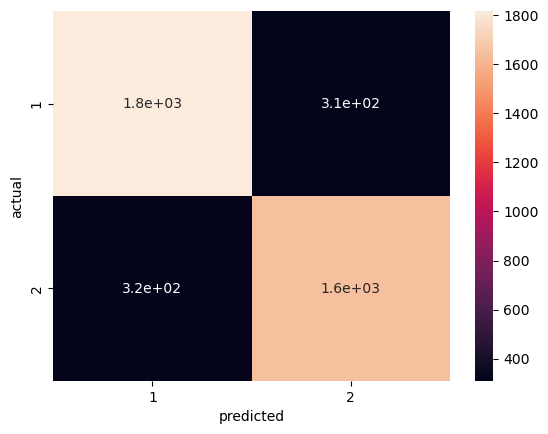

In [18]:
#visualization for generic binary
data = {"y_predicted":y_pred,"y_actual":y_test}
df_conf = pd.DataFrame(data,columns=['y_actual',"y_predicted"])
confusion_matrix = pd.crosstab(df_conf['y_actual'],df_conf["y_predicted"],
                               rownames=['actual'],colnames=['predicted'])

sns.heatmap(confusion_matrix,annot=True)

In [19]:
##naive bayes with generic (contains neutral)
# Feature and target variables
X = generic['clean_text']
y = generic['sentiment']

# Text vectorization
count_vectorizer = CountVectorizer(max_features=1000)
X_transformed = count_vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, random_state=42)

# Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.71      0.65      2787
           1       0.73      0.67      0.70      2127
           2       0.69      0.56      0.62      1957

    accuracy                           0.66      6871
   macro avg       0.67      0.65      0.66      6871
weighted avg       0.67      0.66      0.66      6871



<Axes: xlabel='predicted', ylabel='actual'>

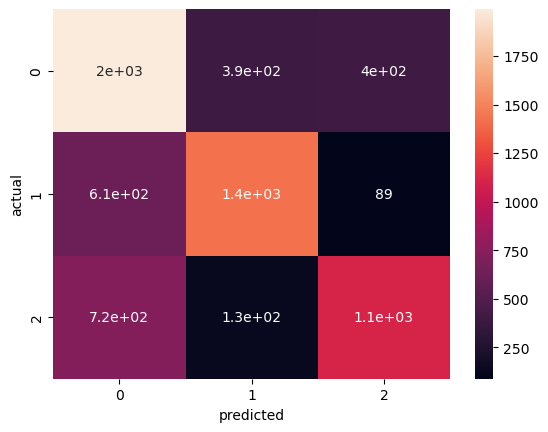

In [20]:
#visualization for generic binary
data = {"y_predicted":y_pred,"y_actual":y_test}
df_conf = pd.DataFrame(data,columns=['y_actual',"y_predicted"])
confusion_matrix = pd.crosstab(df_conf['y_actual'],df_conf["y_predicted"],
                               rownames=['actual'],colnames=['predicted'])

sns.heatmap(confusion_matrix,annot=True)

In [21]:
#not clean version (just curious lol)
##naive bayes with generic_binary
# Feature and target variables
X = generic_binary['text']
y = generic_binary['sentiment']

# Text vectorization
count_vectorizer = CountVectorizer(max_features=1000)
X_transformed = count_vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, random_state=42)

# Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.84      0.85      2127
           2       0.83      0.86      0.85      1964

    accuracy                           0.85      4091
   macro avg       0.85      0.85      0.85      4091
weighted avg       0.85      0.85      0.85      4091



In [22]:
##unclean version - naive bayes with generic (contains neutral)
# Feature and target variables
X = generic['text']
y = generic['sentiment']

# Text vectorization
count_vectorizer = CountVectorizer(max_features=1000)
X_transformed = count_vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.25, random_state=42)

# Naive Bayes model
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Classification Report:\n{class_report}")

Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.70      0.65      2787
           1       0.74      0.67      0.70      2127
           2       0.67      0.58      0.62      1957

    accuracy                           0.66      6871
   macro avg       0.67      0.65      0.66      6871
weighted avg       0.66      0.66      0.66      6871



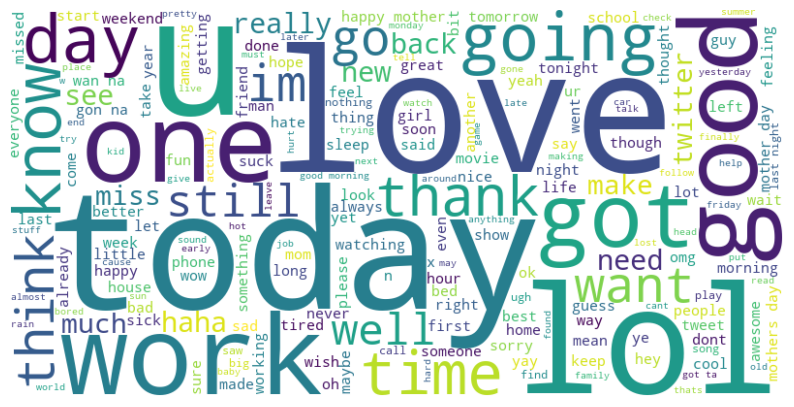

In [23]:
# Word cloud of the text in the dataset (Rose)
text_data = ' '.join(generic['clean_text'].dropna())

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.show()